### Imports and Default Parameters

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import seaborn as sns

from scipy import stats
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from spectral_clustering.metrics.clustering import clustering_scores, run_iters, bar_comparison, point_comparison, boxplot_with_mean, line_comparison, prepare_line_summary, calculate_neighbourhood_purity, bootstrap_ci, summarise
from spectral_clustering.graphs import knn_graph, fully_connected
from spectral_clustering.models.spectral import BaseSpectralClustering

pca = PCA(n_components=32, random_state=0)

CIFAR_labels = np.load('simclr_testing/CIFAR_simclr/labels.npy')
CIFAR_raw = np.load('simclr_testing/CIFAR_simclr/raw.npy')
CIFAR_vae = np.load('simclr_testing/CIFAR_VAE_v1/latents_train_epoch_300.npz')['latents']
CIFAR_simclr = np.load('simclr_testing/CIFAR_simclr/latents_1000.npy')
CIFAR_simclr_pca = pca.fit_transform(CIFAR_simclr)

FMNIST_labels = np.load('simclr_testing/FashionMNIST_simclr/labels.npy')
FMNIST_raw = np.load('simclr_testing/FashionMNIST_simclr/raw.npy')
FMNIST_vae = np.load('./datasets/FashionMNIST/FashionMNIST_vae_1000.npz')['arr_0']
FMNIST_simclr = np.load('simclr_testing/FashionMNIST_simclr/latents_1000.npy')
FMNIST_simclr_pca = pca.fit_transform(FMNIST_simclr)

MNIST_labels = np.load('./datasets/MNIST/MNIST_labels.npz')['arr_0']
MNIST_raw = np.load('./datasets/MNIST/MNIST_raw.npz')['arr_0']
MNIST_vae = np.load('./datasets/MNIST/MNIST_VAE_1000.npz')['arr_0']
MNIST_simclr = np.load('simclr_testing/MNIST_simclr/latents_100.npz')['latents']
MNIST_simclr_pca = pca.fit_transform(MNIST_simclr)

dataset_names = ['CIFAR_raw', 'CIFAR_vae', 'CIFAR_simclr', 'CIFAR_simclr_pca', 'FMNIST_raw', 'FMNIST_vae', 'FMNIST_simclr', 'FMNIST_simclr_pca', 'MNIST_raw', 'MNIST_vae', 'MNIST_simclr', 'MNIST_simclr_pca']
X = [CIFAR_raw, CIFAR_vae, CIFAR_simclr, CIFAR_simclr_pca, FMNIST_raw, FMNIST_vae, FMNIST_simclr, FMNIST_simclr_pca, MNIST_raw, MNIST_vae, MNIST_simclr, MNIST_simclr_pca]
Y = [CIFAR_labels, CIFAR_labels, CIFAR_labels, CIFAR_labels, FMNIST_labels, FMNIST_labels, FMNIST_labels, FMNIST_labels, MNIST_labels, MNIST_labels, MNIST_labels, MNIST_labels]

In [35]:
plt.rcParams.update({
    # --- Font ---
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'axes.unicode_minus': False,

    # --- Font sizes ---
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,   # was 11
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,

    # --- Figure ---
    'figure.figsize': (7, 4.2),
    'figure.dpi': 300,
    'figure.facecolor': 'white',

    # --- Axes ---
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'axes.grid': False,

    # --- Grid ---
    'grid.color': '0.85',
    'grid.linestyle': '-',
    'grid.linewidth': 0.5,

    # --- Ticks ---
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,

    # --- Lines ---
    'lines.linewidth': 1.5,

    # --- Legend ---
    'legend.frameon': False,

    # --- Savefig ---
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white'
})

COLORS = {
    'raw': '#666666',
    'vae': '#0072B2',
    'simclr': '#009E73',
    'simclr_pca': '#D55E00',

    # graph-building methods
    'knn': '#666666',
    'fc': '#0072B2',
    'adaptive': '#009E73',
    'biclique': '#D55E00',
    'pcan': '#CC79A7',
}

## Sweep analysis

In [36]:
adaptive_k_sweep = pd.read_csv('accuracies/learned_reps/adaptive/adaptive_k_sweep.csv')
adaptive_k_sweep_timings = pd.read_csv('accuracies/learned_reps/adaptive/timings_adaptive_k_sweep.csv')

knn_k_sweep = pd.read_csv('accuracies/learned_reps/knn/knn_k_sweep.csv')
knn_k_sweep_timings = pd.read_csv('accuracies/learned_reps/knn/timings_knn_k_sweep.csv')

biclique_k_sweep = pd.read_csv('accuracies/learned_reps/biclique/biclique_k_sweep.csv')
biclique_k_sweep_timings = pd.read_csv('accuracies/learned_reps/biclique/timings_biclique_k_sweep.csv')
biclique_r_sweep = pd.read_csv('accuracies/learned_reps/biclique/biclique_r_sweep.csv')
biclique_r_sweep_timings = pd.read_csv('accuracies/learned_reps/biclique/timings_biclique_r_sweep.csv')

In [37]:
adaptive_k_sweep.sort_values('mean', ascending=False).groupby('dataset').first()

,k,mean,std
dataset,,,
CIFAR_raw,50,21.128200,0.497856
CIFAR_simclr,250,77.396760,0.576616
CIFAR_simclr_pca,300,77.318580,0.640907
CIFAR_vae,15,26.968480,0.601256
FMNIST_raw,10,57.023467,1.549229
FMNIST_simclr,250,63.499483,2.149084
FMNIST_simclr_pca,250,62.989233,2.246735
FMNIST_vae,500,60.409000,2.714398
MNIST_raw,5,73.130317,3.602638


In [38]:
knn_k_sweep.sort_values('mean', ascending=False).groupby('dataset').first()

,k,mean,std
dataset,,,
CIFAR_raw,20,20.950500,0.121081
CIFAR_simclr,50,76.624320,1.845040
CIFAR_simclr_pca,350,77.641220,1.344287
CIFAR_vae,25,27.144280,0.302761
FMNIST_raw,10,57.441367,1.133288
FMNIST_simclr,250,63.701033,2.409742
FMNIST_simclr_pca,250,63.499467,2.674327
FMNIST_vae,450,58.419383,2.929338
MNIST_raw,5,72.370883,3.198788


In [39]:
biclique_k_sweep.sort_values('mean', ascending=False).groupby('dataset').first()

,k,mean,std
dataset,,,
CIFAR_raw,10,21.612140,0.445748
CIFAR_simclr,450,79.869580,2.009769
CIFAR_simclr_pca,150,78.161380,1.370821
CIFAR_vae,50,25.134000,0.602529
FMNIST_raw,250,62.258650,1.892423
FMNIST_simclr,350,61.355183,2.312472
FMNIST_simclr_pca,250,61.064717,2.794772
FMNIST_vae,5,66.040733,1.909612
MNIST_raw,5,78.259650,3.612448


In [40]:
biclique_r_sweep.sort_values('mean', ascending=False).groupby('dataset').first()

,r,mean,std
dataset,,,
CIFAR_simclr,4,79.727920,2.158082
CIFAR_simclr_pca,14,77.355520,1.196858
CIFAR_vae,20,24.986260,0.302247
FMNIST_simclr,4,60.497683,3.280314
FMNIST_simclr_pca,4,60.264183,2.408083
FMNIST_vae,4,54.408967,2.613374
MNIST_simclr,8,96.287767,0.000861
MNIST_simclr_pca,4,95.668367,0.887714
MNIST_vae,8,80.691633,4.955493


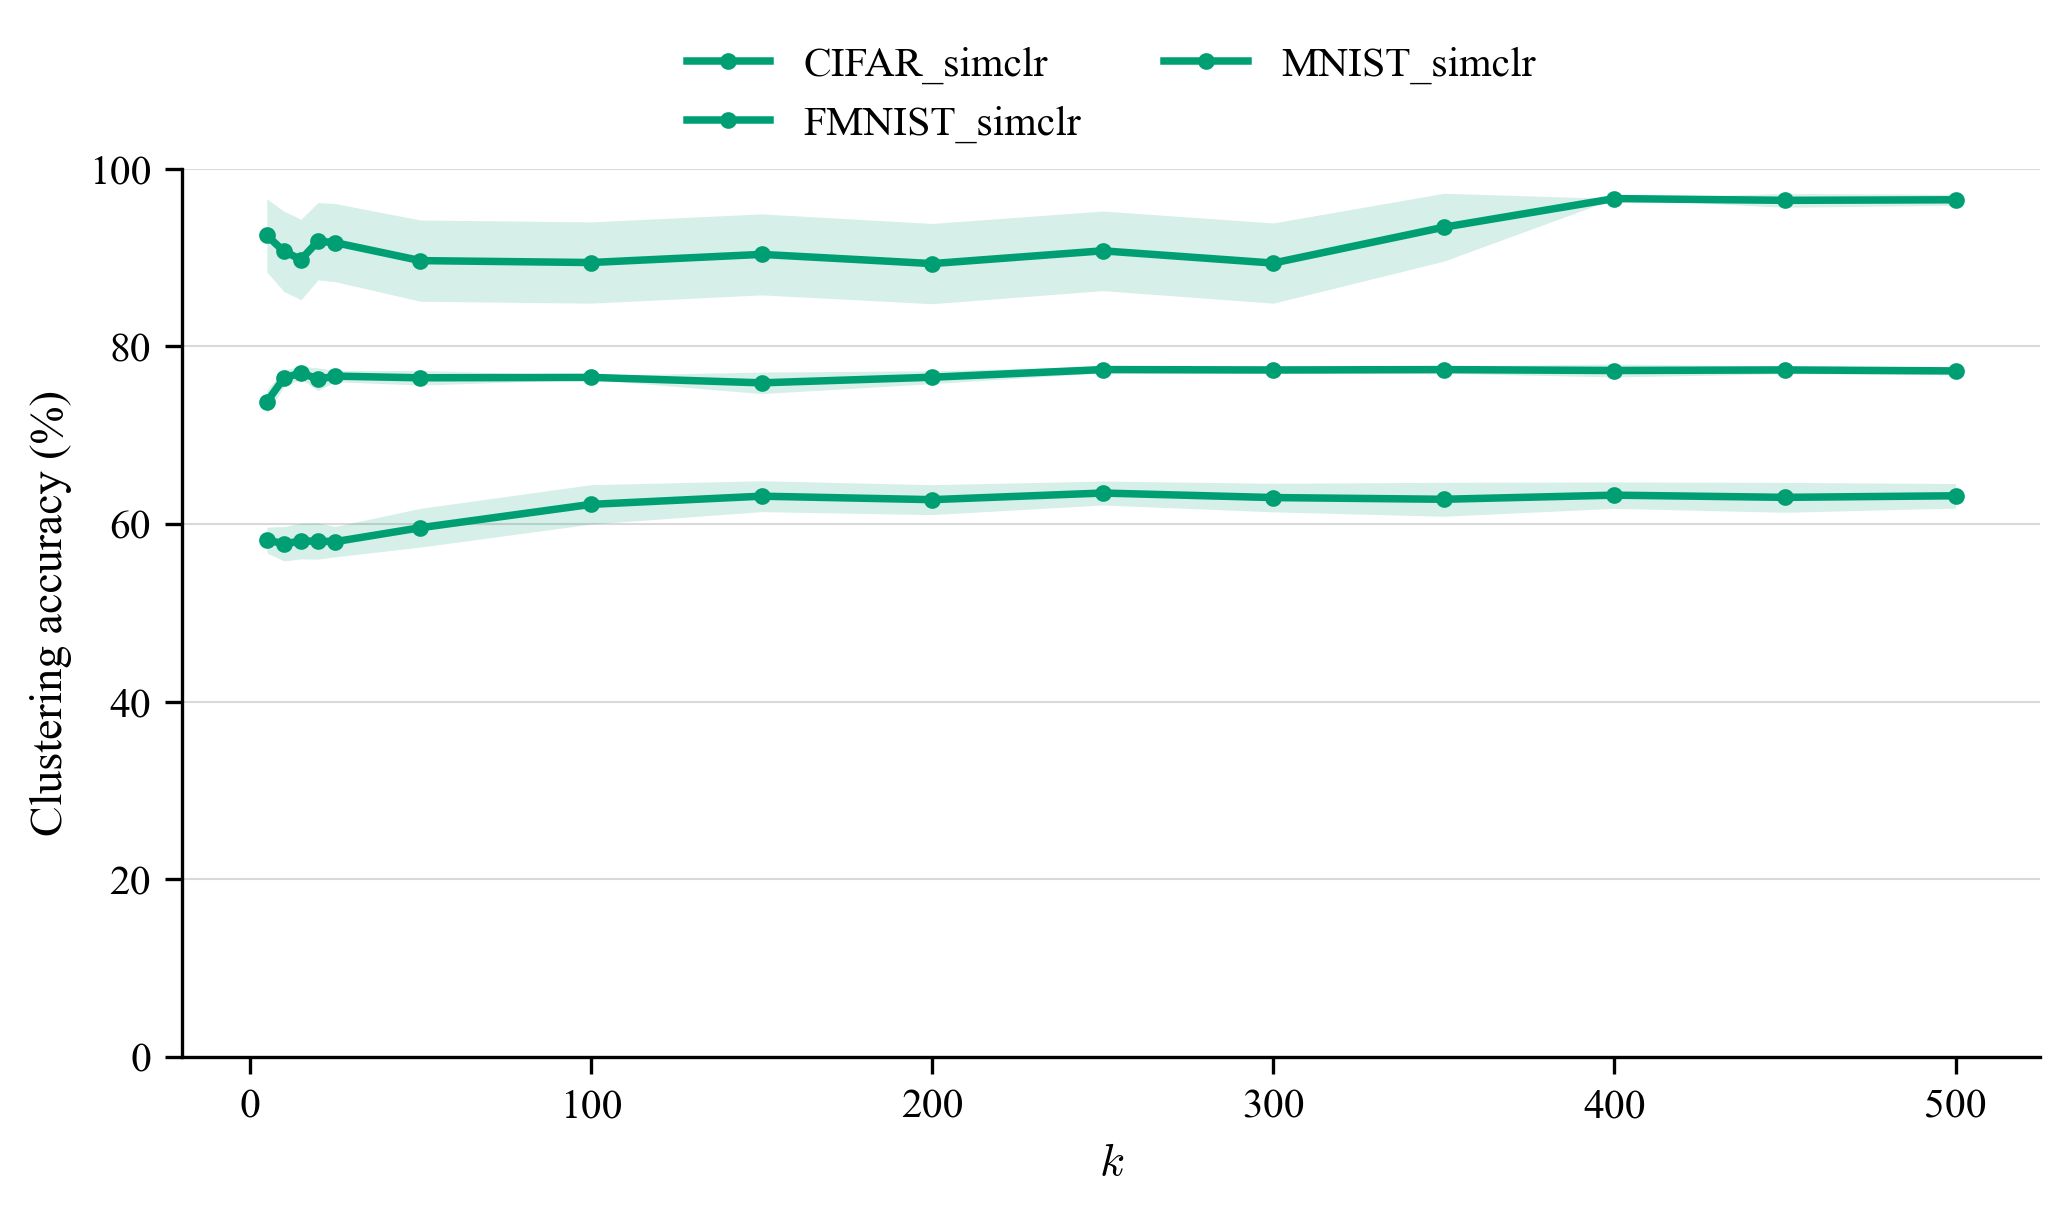

In [67]:
adaptive_acc = pd.read_csv('accuracies/learned_reps/adaptive/adaptive_k_sweep.csv')
adaptive_acc = adaptive_acc[adaptive_acc['dataset'].str.endswith('simclr')]

tcrit = stats.t.ppf(0.975, df=99)
adaptive_acc['sem'] = adaptive_acc['std'] / np.sqrt(10)
adaptive_acc['ci'] = tcrit * adaptive_acc['sem']
adaptive_acc['lower'] = adaptive_acc['mean'] - adaptive_acc['ci']
adaptive_acc['upper'] = adaptive_acc['mean'] + adaptive_acc['ci']
adaptive_acc

line_comparison(adaptive_acc, x='k', series='dataset', xlabel=r'$k$', markersize=3, filename=None, ylim=(0,100))